<a href="https://colab.research.google.com/github/Only-Eni/Google-Developers-Group-Campus/blob/main/GDG_AI_DAY_8_NUMPY_PANDAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("data.csv")

# Display first rows
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,68.437500,103.500000,128.500000,304.680000
std,70.039591,7.832933,12.998759,66.003779
min,30.000000,90.000000,101.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,127.500000,291.200000
75%,60.000000,106.500000,132.250000,343.975000
max,450.000000,130.000000,175.000000,479.000000


In [5]:
# Define X (features) and y (target)

X = df[["Duration", "Pulse", "Maxpulse"]]
y = df["Calories"]

X.head()

,Duration,Pulse,Maxpulse
0,60,110,130
1,60,117,145
2,60,103,135
3,45,109,175
4,45,117,148


In [6]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((25, 3), (7, 3))

In [7]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Handle NaN values in y_train by dropping corresponding rows in X_train and y_train
valid_indices = y_train.dropna().index
X_train_cleaned = X_train.loc[valid_indices]
y_train_cleaned = y_train.loc[valid_indices]

# Train model with cleaned data
model.fit(X_train_cleaned, y_train_cleaned)

# Model coefficients
model.coef_, model.intercept_

(array([-0.15394694,  4.36460008,  1.47258709]),
 np.float64(-322.96911881051545))

In [8]:
# Predict on test data
y_pred = model.predict(X_test)

# Compare predictions with actual values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
0,280.0,298.635569
1,275.0,276.653085
2,246.0,322.767774
3,300.0,280.964524
4,195.1,344.007965


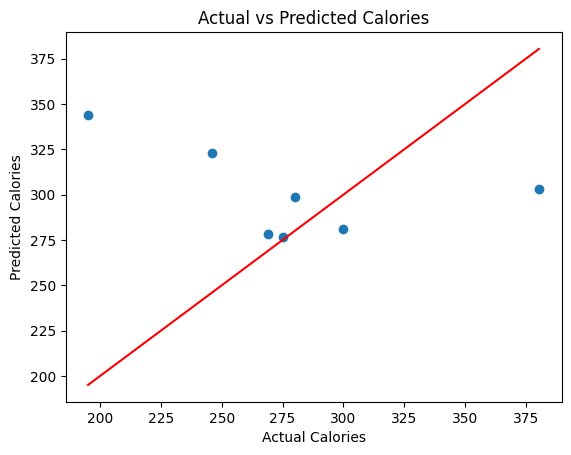

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")

# Add perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

### Actual vs Predicted Calories

This scatter plot compares the `Actual Calories` (from the test set `y_test`) against the `Predicted Calories` (from our Linear Regression model `y_pred`).

*   **What it signifies:**
    *   **Closeness to the red line:** The red line represents a perfect prediction scenario where `Actual Calories = Predicted Calories`. If the points cluster closely around this red line, it indicates that our model is making accurate predictions.
    *   **Scatter:** A wider spread of points around the red line suggests greater prediction error or variance in the model's performance.




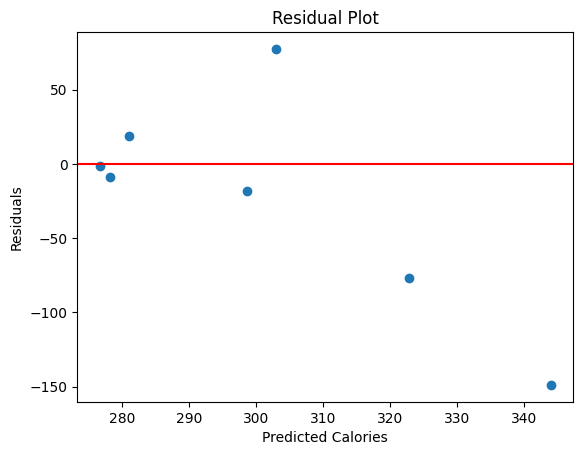

In [10]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Calories")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

###  Residual Plot

A residual plot displays the difference between the actual and predicted values (residuals) against the predicted values. Residuals are calculated as `y_test - y_pred`.

*   **What it signifies:**
    *   **Random scatter around zero:** Ideally, for a good linear model, the residuals should be randomly scattered around the horizontal line at zero. This indicates that the model's errors are random and not systematically related to the predicted values.
    *   **Patterns (e.g., funnel shape, curve):** If there's a discernible pattern (like a funnel shape, a curve, or points consistently above or below zero for certain ranges), it suggests that the linear model might not be appropriate, or there might be heteroscedasticity (unequal variance of errors) or other issues that violate the assumptions of linear regression.

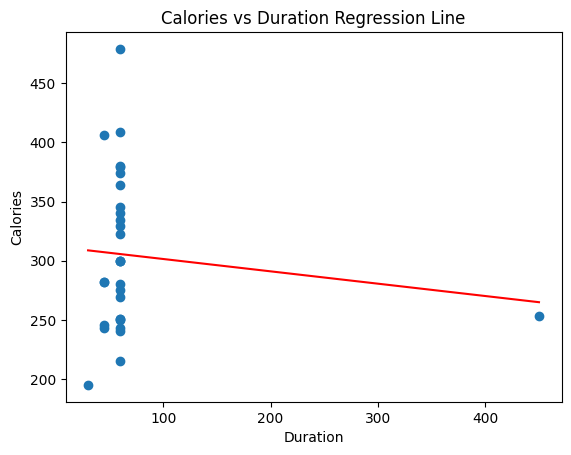

In [11]:
plt.scatter(df["Duration"], df["Calories"])

# Fit simple regression line
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

X_simple = df[["Duration"]]
y_simple = df["Calories"]

# Handle NaN values in y_simple by dropping corresponding rows in X_simple and y_simple
valid_indices_simple = y_simple.dropna().index
X_simple_cleaned = X_simple.loc[valid_indices_simple]
y_simple_cleaned = y_simple.loc[valid_indices_simple]

model_simple = LinearRegression()
model_simple.fit(X_simple_cleaned, y_simple_cleaned)

x_range = np.linspace(df["Duration"].min(), df["Duration"].max(), 100)
# Convert x_range to a DataFrame with the same column name as X_simple_cleaned
x_range_df = pd.DataFrame(x_range.reshape(-1, 1), columns=X_simple_cleaned.columns)
y_line = model_simple.predict(x_range_df)

plt.plot(x_range, y_line, color='red')
plt.xlabel("Duration")
plt.ylabel("Calories")
plt.title("Calories vs Duration Regression Line")
plt.show()

### Calories vs Duration Regression Line

This scatter plot shows the relationship between `Duration` (an independent variable) and `Calories` (the dependent variable), overlaid with a simple linear regression line.

*   **What it signifies:**
    *   **Direction of relationship:** The slope of the red line indicates the direction of the relationship. An upward-sloping line suggests a positive correlation (as Duration increases, Calories tend to increase), while a downward-sloping line suggests a negative correlation.
    *   **Strength of relationship:** How closely the scatter points cluster around the red line indicates the strength of the linear relationship. A tight cluster suggests a strong relationship, while a wide spread indicates a weaker one.
    *   **Visual fit:** This plot provides a visual assessment of how well a simple linear model captures the trend between these two specific variables.

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2

(50.21121908478479, -0.8398442177066554)

### Model Evaluation Metrics

The previous cell calculated two key metrics to evaluate the performance of our Linear Regression model:

*   **Mean Absolute Error (MAE)**: `50.21121908478479`
    *   **What it signifies:** MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute differences between the actual (`y_test`) and predicted (`y_pred`) values. A lower MAE indicates a more accurate model, as it means, on average, your predictions are closer to the actual values.

*   **R-squared (R2 Score)**: `-0.8398442177066554`
    *   **What it signifies:** R-squared (coefficient of determination) represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where 1 means the model perfectly predicts the target variable.
    *   **Interpretation of a negative R2:** A negative R-squared, as seen in the output, is a strong indicator that the model is a very poor fit for the data. It means the model performs worse than simply predicting the mean of the target variable for all observations. This often suggests that the chosen features (Duration, Pulse, Maxpulse) or the linear model itself are not suitable for predicting 'Calories' in this dataset, or that there are significant issues with the data or model assumptions.